# **Prediksi Churn Pelanggan**

# Week 3 - Modeling Dengan Preprocessing

**Dataset:** Sales and Marketing Customer Dataset  
**Unit Kompetensi:** Membangun model dan menghasilkan prediksi dengan data yang bersih.


## Load Data & Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/bengkod-churn/dataset/Sales - Marketing customer dataset.csv')
print(f'Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.')

Mounted at /content/drive
Dataset berhasil dimuat dengan 15000 baris dan 30 kolom.


## 1. Melakukan preprocessing data

### Penanganan Missing Value

In [ ]:
# Penanganan Missing Value Berdasarkan Distribusi
# Modus untuk kategorikal
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

# Median untuk numerik yang memiliki outlier/skewed
df['age'] = df['age'].fillna(df['age'].median())
df['total_spent'] = df['total_spent'].fillna(df['total_spent'].median())
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

print('Missing values ditangani dengan Median (numerik) dan Modus (kategorikal).')

Missing values ditangani dengan Median (numerik) dan Modus (kategorikal).


### Penanganan Duplikasi Data

In [ ]:
print('--- Cek Duplikasi Data ---')
initial_rows = df.shape[0]
duplicated_rows = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicated_rows}')

if duplicated_rows > 0:
    df.drop_duplicates(inplace=True)
    print(f'Jumlah baris setelah menghapus duplikasi: {df.shape[0]}')
    print('Duplikasi data berhasil ditangani.')
else:
    print('Tidak ditemukan duplikasi data.')

--- Cek Duplikasi Data ---
Jumlah baris duplikat: 0
Tidak ditemukan duplikasi data.


### Penanganan Outliers

In [ ]:
print('--- Cek dan Penanganan Outliers ---')

# Memilih kolom numerik untuk deteksi outlier
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Kolom yang sudah ditangani missing value sebelumnya dan relevan untuk outlier
# 'coupon_code' dikecualikan karena penanganan missing valuenya berbeda/non-numerik
relevant_numeric_cols = ['age', 'total_spent', 'satisfaction_score']

for col in relevant_numeric_cols:
    print(f'\nProcessing column: {col}')
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f'Jumlah outliers di kolom {col}: {outliers_count}')

    if outliers_count > 0:
        # Capping outliers (mengganti nilai outlier dengan batas IQR terdekat)
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        print(f'Outliers di kolom {col} telah ditangani dengan capping.')
    else:
        print(f'Tidak ada outliers signifikan di kolom {col}.')

print('\nPenanganan outliers selesai.')

--- Cek dan Penanganan Outliers ---

Processing column: age
Jumlah outliers di kolom age: 218
Outliers di kolom age telah ditangani dengan capping.

Processing column: total_spent
Jumlah outliers di kolom total_spent: 119
Outliers di kolom total_spent telah ditangani dengan capping.

Processing column: satisfaction_score
Jumlah outliers di kolom satisfaction_score: 753
Outliers di kolom satisfaction_score telah ditangani dengan capping.

Penanganan outliers selesai.


### **Analisis dan Penanganan Outliers**

Berdasarkan hasil deteksi di atas, terdapat outlier pada kolom berikut:
1.  **age** (218 outlier)
2.  **total_spent** (119 outlier)
3.  **satisfaction_score** (753 outlier)

**Alasan Penanganan dengan Capping:**
Outlier pada fitur-fitur ini ditangani menggunakan metode **Capping (Winsorizing)** pada batas IQR. Alasan logisnya adalah:
*   **Menjaga Ukuran Data:** Kita tidak menghapus baris agar tidak kehilangan informasi penting dari fitur lain pada pelanggan tersebut.
*   **Mengurangi Bias:** Dengan membatasi nilai ekstrim ke batas atas/bawah yang wajar, kita mencegah model (terutama model sensitif seperti Logistic Regression) memberikan bobot yang terlalu besar pada nilai ekstrim, sehingga hasil prediksi menjadi lebih stabil dan generalis.

### Encoding untuk fitur kategorikal

In [ ]:
# Feature Engineering untuk Tanggal & Encoding
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'])

# Ubah tanggal menjadi fitur numerik (jumlah hari)
ref_date = df['last_purchase_date'].max()
df['days_since_signup'] = (ref_date - df['signup_date']).dt.days
df['days_since_last_purchase'] = (ref_date - df['last_purchase_date']).dt.days

# Identifikasi kolom untuk One-Hot Encoding (hanya yang kardinalitas rendah)
# Kita kecualikan kolom ID, tanggal mentah, dan kolom yang terlalu unik
ignore_cols = ['customer_id', 'coupon_code', 'signup_date', 'last_purchase_date', 'country', 'city']
cat_to_encode = [c for c in df.select_dtypes(include='object').columns if c not in ignore_cols]

df_encoded = pd.get_dummies(df.drop(columns=['signup_date', 'last_purchase_date']),
                            columns=cat_to_encode, drop_first=True, dtype=int)

print(f'Strategi encoding selesai. Fitur baru: {df_encoded.shape[1]} kolom.')
print(df_encoded[['days_since_signup', 'days_since_last_purchase']].head())

Strategi encoding selesai. Fitur baru: 38 kolom.
   days_since_signup  days_since_last_purchase
0               1035                        69
1                267                       307
2                565                       316
3                407                       660
4                598                       337


### Analisis Mendalam: Distribusi, Outlier, dan Kardinalitas

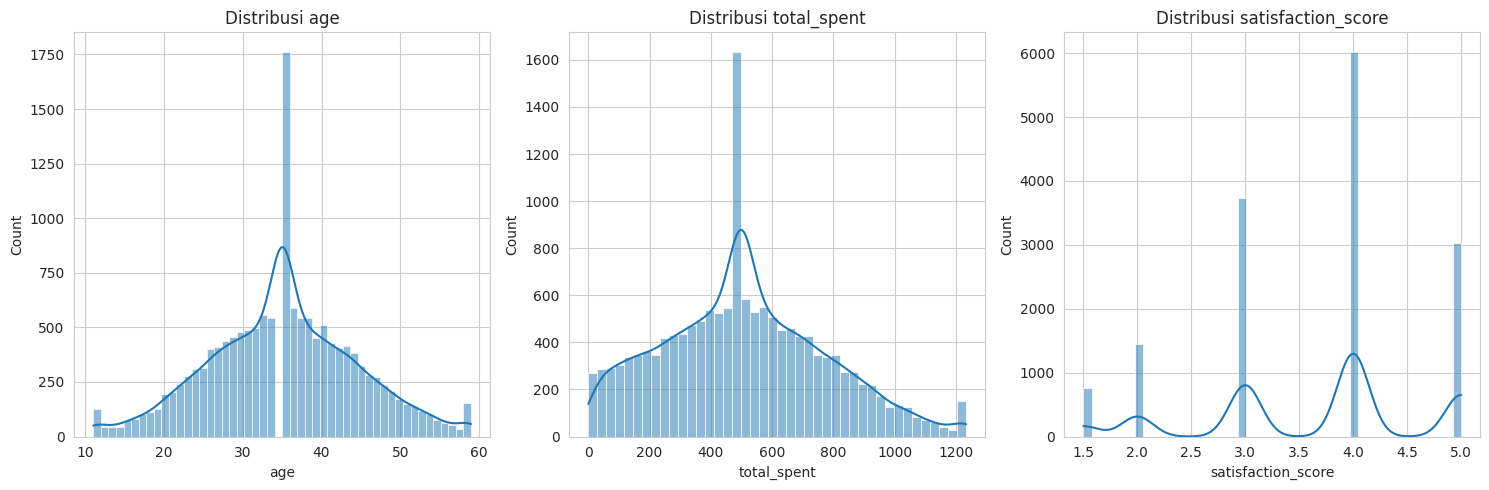

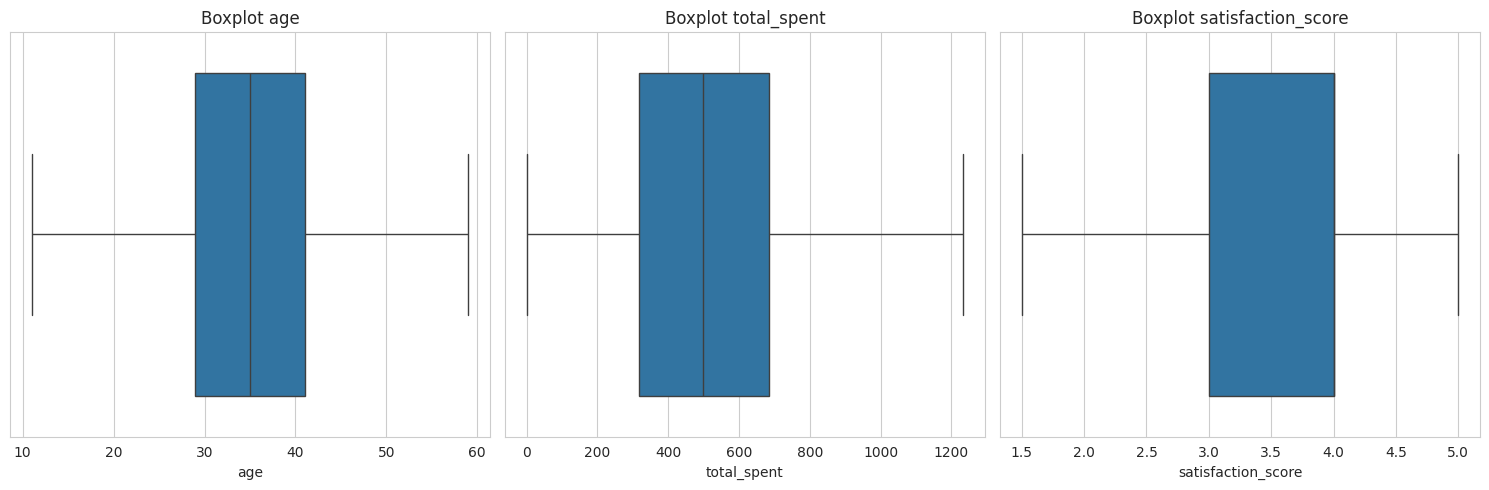

In [ ]:
# 1. Cek Distribusi dan Outlier secara Visual
cols_to_viz = ['age', 'total_spent', 'satisfaction_score']
plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_to_viz, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_viz, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

### Cek Nilai Unik (Kardinalitas) untuk Strategi Encoding
Jika nilai unik terlalu banyak (seperti `signup_date`), One-Hot Encoding akan menghasilkan ribuan kolom baru yang membuat model tidak efisien.

In [ ]:
# 2. Cek Kardinalitas Kolom Kategorikal
cat_features = df.select_dtypes(include=['object']).columns
for col in cat_features:
    print(f'{col}: {df[col].nunique()} nilai unik')

# Saran: Kolom tanggal sebaiknya diekstrak fiturnya (bulan/tahun) daripada langsung di-encode.
# Kolom country/city jika terlalu banyak bisa menggunakan Label Encoding atau Target Encoding.

gender: 3 nilai unik
country: 5 nilai unik
city: 7 nilai unik
acquisition_channel: 5 nilai unik
device_type: 3 nilai unik
subscription_type: 2 nilai unik
coupon_code: 3 nilai unik
payment_method: 5 nilai unik


Pada proses encoding, beberapa kolom tidak ikut diubah ke bentuk numerik, diantaranya:
1. Kolom **customer_id** tidak digunakan karena hanya berisi ID unik pelanggan dan tidak memberikan informasi yang dapat membantu model dalam membuat prediksi.
2. Kolom **coupon_code** juga dikecualikan karena memiliki banyak data yang kosong (missing values) dan dianggap kurang relevan untuk analisis.
3. Kolom **country** dan **city** tidak di-encode karena memiliki terlalu banyak kategori yang berbeda, sehingga dapat membuat data menjadi lebih kompleks.
4. Kolom **membership_level** meskipun sebenarnya memiliki tingkatan tertentu, pada tahap ini kolom tersebut diperlakukan sebagai kategori biasa agar proses preprocessing lebih sederhana dan mudah dilakukan.

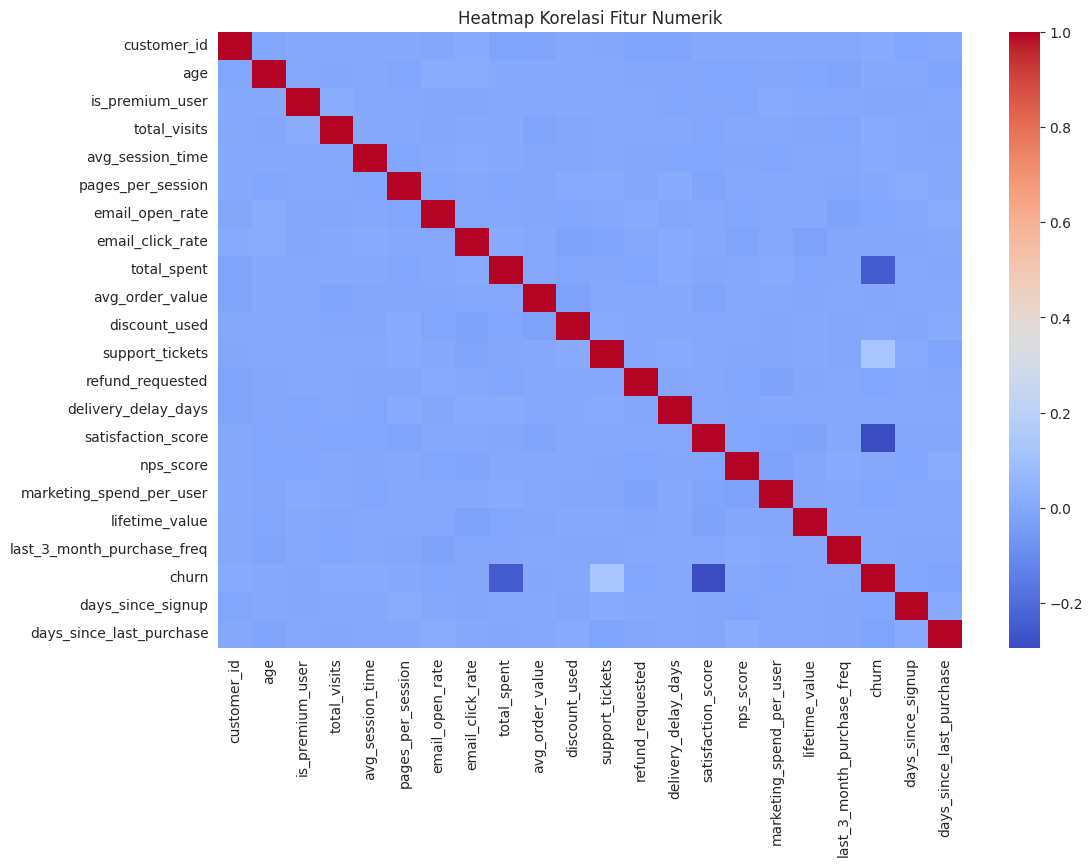

In [ ]:
# Visualisasi Korelasi
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

### Scaling fitur jika diperlukan. Scaling dilakukan setelah data splitting.

In [ ]:
# Memisahkan fitur (X) dan target (y)
# 'churn' adalah target variabel kita
# 'customer_id' dan 'coupon_code' (jika masih ada dan belum dihapus/diencode) tidak digunakan sebagai fitur
# Pastikan 'df_encoded' sudah tersedia dari langkah encoding sebelumnya

X = df_encoded.drop(columns=['churn', 'customer_id', 'coupon_code'])
y = df_encoded['churn']

print(f'Fitur (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')

# Membagi data menjadi training dan testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print('\n--- Feature Scaling ---')

# Identifikasi kolom numerik yang perlu di-scaling
# Exclude biner (0/1) dari one-hot encoding karena tidak perlu di-scale
numerical_cols_to_scale = X_train.select_dtypes(include=np.number).columns.tolist()

# Kolom yang mungkin biner setelah one-hot encoding, tidak perlu di-scale lagi.
# Kita akan menghapus kolom-kolom yang kemungkinan merupakan hasil one-hot encoding
# dari daftar kolom yang akan di-scale.
# Asumsi kolom one-hot encoding dimulai dengan nama kolom asli diikuti underscore.

# Contoh: Identifikasi kolom yang bukan one-hot-encoded dengan melihat apakah nilainya hanya 0 dan 1
# Atau dengan mengecualikan kolom dari list `cols_to_encode` yang sudah di-get_dummies

# Lebih aman, kita ambil kolom numerik asli dari df sebelum encoding,
# kemudian filter yang masih ada di X_train (setelah drop customer_id, churn, coupon_code)
original_numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove 'customer_id' and 'churn' from this list, as they are handled
if 'customer_id' in original_numerical_cols: original_numerical_cols.remove('customer_id')
if 'churn' in original_numerical_cols: original_numerical_cols.remove('churn')

# Filter out 'coupon_code' if it was originally numerical (unlikely but safe check)
if 'coupon_code' in original_numerical_cols: original_numerical_cols.remove('coupon_code')

# Kolom yang perlu di-scale adalah kolom numerik asli yang bukan biner (0/1)
# dan bukan merupakan hasil dari one-hot encoding atau ID
features_to_scale = [col for col in original_numerical_cols if col in X_train.columns and
                     not (X_train[col].nunique() == 2 and X_train[col].min() == 0 and X_train[col].max() == 1)]

# Manual check for 'is_premium_user' which is binary but might be in original_numerical_cols
if 'is_premium_user' in features_to_scale:
    features_to_scale.remove('is_premium_user')

print(f'Kolom yang akan di-scale: {features_to_scale}')

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit scaler hanya pada data training dan transformasikan keduanya
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

print('\nData training setelah scaling:')
print(X_train[features_to_scale].head())
print('\nData testing setelah scaling:')
print(X_test[features_to_scale].head())

print('\nFeature scaling selesai.')

Fitur (X) shape: (15000, 35)
Target (y) shape: (15000,)
X_train shape: (12000, 35)
X_test shape: (3000, 35)
y_train shape: (12000,)
y_test shape: (3000,)

--- Feature Scaling ---
Kolom yang akan di-scale: ['age', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'support_tickets', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'days_since_signup', 'days_since_last_purchase']

Data training setelah scaling:
            age  total_visits  avg_session_time  pages_per_session  \
8722  -0.125352     -1.800890          0.658691          -1.160708   
12778 -0.019525     -0.257490          0.119994           0.829867   
11229 -0.125352     -1.029190          0.363930          -0.708615   
4671   0.721264     -1.029190         -0.357159          -0.061085   
4247   0.615437     -0.514724         -0.341088          -1.119811   

  

### Penghapusan fitur yang tidak relevan

In [ ]:
# Menghapus fitur 'country' dan 'city' dari X_train dan X_test
# Karena kolom ini tidak di-encode karena kardinalitas tinggi
# dan tidak relevan untuk model tanpa preprocessing lebih lanjut
print("--- Menghapus fitur 'country' dan 'city' ---")
if 'country' in X_train.columns:
    X_train = X_train.drop(columns=['country'])
    X_test = X_test.drop(columns=['country'])
    print("Kolom 'country' berhasil dihapus dari X_train dan X_test.")
else:
    print("Kolom 'country' tidak ditemukan di X_train atau sudah dihapus.")

if 'city' in X_train.columns:
    X_train = X_train.drop(columns=['city'])
    X_test = X_test.drop(columns=['city'])
    print("Kolom 'city' berhasil dihapus dari X_train dan X_test.")
else:
    print("Kolom 'city' tidak ditemukan di X_train atau sudah dihapus.")

print(f'\nShape X_train setelah penghapusan: {X_train.shape}')
print(f'Shape X_test setelah penghapusan: {X_test.shape}')

--- Menghapus fitur 'country' dan 'city' ---
Kolom 'country' berhasil dihapus dari X_train dan X_test.
Kolom 'city' berhasil dihapus dari X_train dan X_test.

Shape X_train setelah penghapusan: (12000, 33)
Shape X_test setelah penghapusan: (3000, 33)


## 2. Penetapan fitur prediktor (X) dan variabel target (y) setelah preprocessing

In [ ]:
# Menetapkan kembali fitur prediktor (X) dan variabel target (y) setelah seluruh tahap preprocessing
# Ini mencakup penghapusan 'customer_id', 'coupon_code', 'country', dan 'city'

X = df_encoded.drop(columns=['churn', 'customer_id', 'coupon_code', 'country', 'city'])
y = df_encoded['churn']

print(f'Fitur (X) setelah preprocessing: {X.shape}')
print(f'Target (y) setelah preprocessing: {y.shape}')

print('\nContoh 5 baris pertama dari X setelah preprocessing:')
print(X.head())
print('\nContoh 5 baris pertama dari y setelah preprocessing:')
print(y.head())

Fitur (X) setelah preprocessing: (15000, 33)
Target (y) setelah preprocessing: (15000,)

Contoh 5 baris pertama dari X setelah preprocessing:
    age  is_premium_user  total_visits  avg_session_time  pages_per_session  \
0  52.0                1             7         13.903745           5.415164   
1  35.0                0            19          5.112528           5.352441   
2  27.0                1            18          9.742749           3.594719   
3  36.0                1            16          9.642654           2.949531   
4  29.0                0            12          7.791291           2.405539   

   email_open_rate  email_click_rate  total_spent  avg_order_value  \
0             0.67              0.26   559.524958        65.246704   
1             0.70              0.37   356.491344        48.473887   
2             0.47              0.44   689.332196        77.815371   
3             0.58              0.37   445.429636        71.712192   
4             0.05              0

## 3. Melakukan train–test split


In [ ]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Shape X_train_final: {X_train_final.shape}')
print(f'Shape X_test_final: {X_test_final.shape}')
print(f'Shape y_train_final: {y_train_final.shape}')
print(f'Shape y_test_final: {y_test_final.shape}')

print('\nTrain-test split berhasil dilakukan dengan data yang sudah di-preprocessing.')

Shape X_train_final: (12000, 33)
Shape X_test_final: (3000, 33)
Shape y_train_final: (12000,)
Shape y_test_final: (3000,)

Train-test split berhasil dilakukan dengan data yang sudah di-preprocessing.


## 4. Melatih ketiga model menggunakan data hasil preprocessing (without tuning)


In [ ]:
# Import model yang akan digunakan
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Inisialisasi daftar model
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'), # liblinear cocok untuk dataset kecil dan kasus L1/L2 penalty
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier': RandomForestClassifier(random_state=42)
}

results = {}

print("--- Melatih dan Mengevaluasi Model ---")

for name, model in models.items():
    print(f'\nMelatih {name}...')
    # Melatih model menggunakan data training final
    model.fit(X_train_final, y_train_final)

    # Memprediksi pada data testing final
    y_pred = model.predict(X_test_final)

    # Mengevaluasi akurasi
    accuracy = accuracy_score(y_test_final, y_pred)
    results[name] = accuracy

    print(f'{name} - Akurasi: {accuracy:.4f}')

print("\n--- Ringkasan Akurasi Model ---")
for name, accuracy in results.items():
    print(f'{name}: {accuracy:.4f}')

--- Melatih dan Mengevaluasi Model ---

Melatih Logistic Regression...
Logistic Regression - Akurasi: 0.8460

Melatih Decision Tree Classifier...
Decision Tree Classifier - Akurasi: 0.8607

Melatih Random Forest Classifier...
Random Forest Classifier - Akurasi: 0.8533

--- Ringkasan Akurasi Model ---
Logistic Regression: 0.8460
Decision Tree Classifier: 0.8607
Random Forest Classifier: 0.8533


## 5. Evaluasi performa model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Evaluasi Performa Model Lengkap ---")

for name, model in models.items():
    print(f'\n==== {name} ====\n')
    # Memprediksi pada data testing final
    y_pred = model.predict(X_test_final)

    # Menampilkan Classification Report
    print("Classification Report:")
    print(classification_report(y_test_final, y_pred))

print('\nEvaluasi Classification Report selesai.')

--- Evaluasi Performa Model Lengkap ---

==== Logistic Regression ====

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.49      0.14      0.21       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.56      3000
weighted avg       0.81      0.85      0.81      3000


==== Decision Tree Classifier ====

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2540
           1       0.55      0.54      0.54       460

    accuracy                           0.86      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.86      0.86      0.86      3000


==== Random Forest Classifier ====

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      2540
           1       0.5

### Confusion Matrix - Logistic Regression

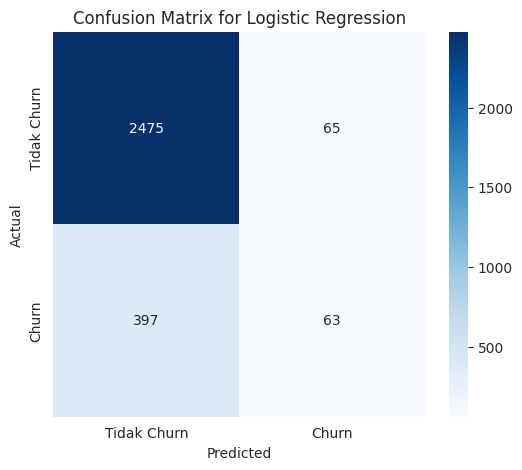

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Memprediksi pada data testing final untuk Logistic Regression
y_pred_lr = models['Logistic Regression'].predict(X_test_final)

# Menampilkan Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test_final, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix - Decision Tree Classifier

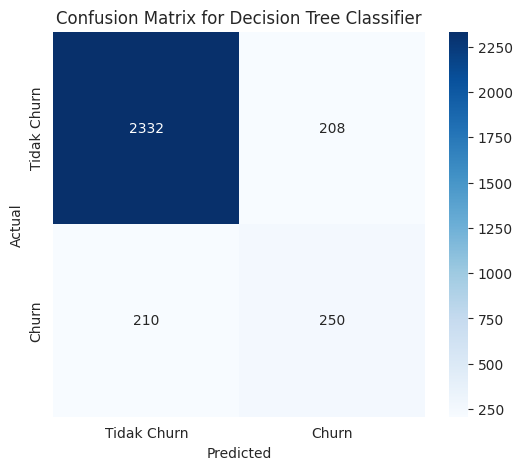

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Memprediksi pada data testing final untuk Decision Tree Classifier
y_pred_dt = models['Decision Tree Classifier'].predict(X_test_final)

# Menampilkan Confusion Matrix for Decision Tree Classifier
cm_dt = confusion_matrix(y_test_final, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Confusion Matrix - Random Forest Classifier

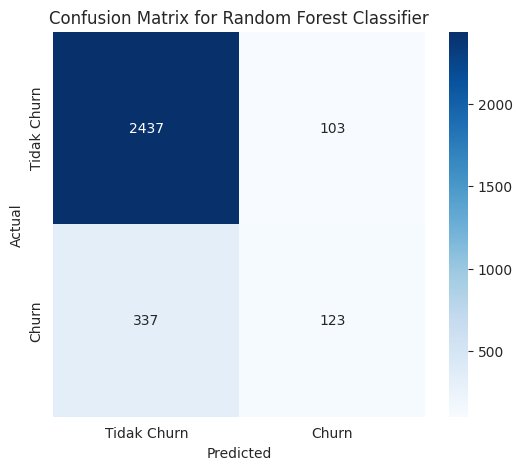

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Memprediksi pada data testing final untuk Random Forest Classifier
y_pred_rf = models['Random Forest Classifier'].predict(X_test_final)

# Menampilkan Confusion Matrix for Random Forest Classifier
cm_rf = confusion_matrix(y_test_final, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Week 4 - Hyperparameter Tuning dan Feature Selection

**Dataset:** Sales and Marketing Customer Dataset  
**Unit Kompetensi:** Mengoptimalkan kinerja model melalui hyperparameter tuning.



### 1. Analisis Feature Importance
Sebelum melakukan Hyperparameter Tuning, kita akan mengevaluasi tingkat kepentingan (importance) dari masing-masing fitur menggunakan model Random Forest. Fitur yang memiliki nilai kontribusi sangat rendah dapat dipertimbangkan untuk dieliminasi agar mempercepat komputasi dan mengurangi noise pada model.

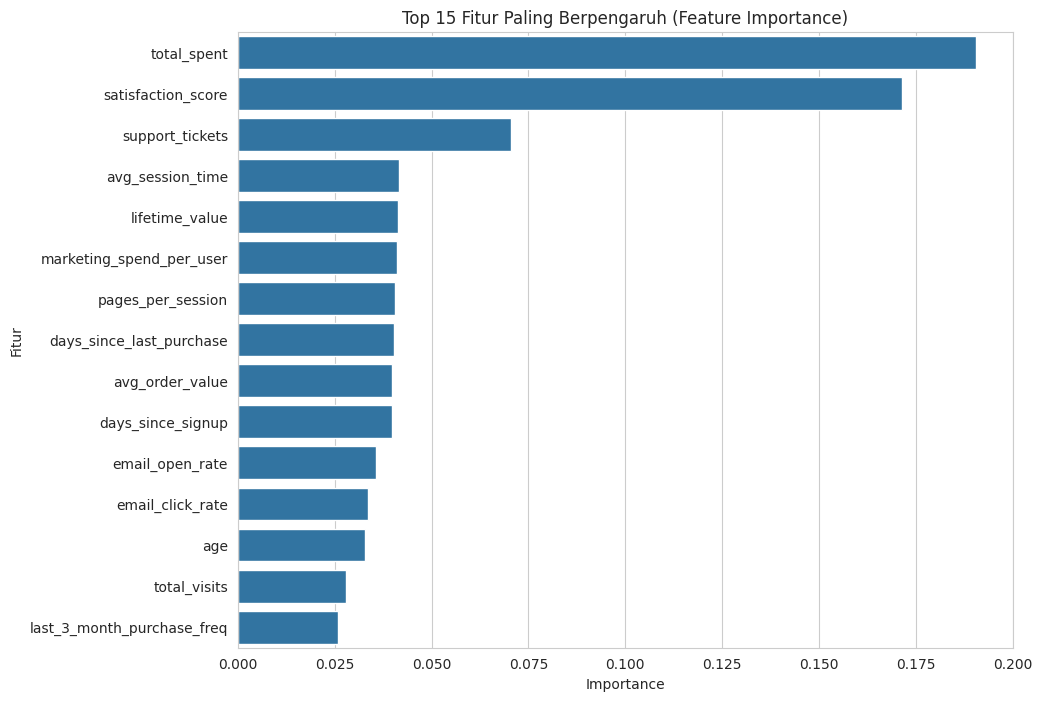

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Tentukan kembali X dan y (Asumsi kolom target bernama 'churn')
# Sesuaikan 'churn' dengan nama kolom target asli di datasetmu
X = df_encoded.drop(columns=['customer_id', 'churn', 'country', 'city', 'coupon_code'], errors='ignore')
y = df_encoded['churn'] if 'churn' in df_encoded.columns else df_encoded.iloc[:, -1] # Fallback jika namanya berbeda

# 2. Train-Test Split (Proporsi sama dengan direct modeling, misal 80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Fit Random Forest untuk mencari Feature Importance
rf_selector = RandomForestClassifier(random_state=42)
rf_selector.fit(X_train, y_train)

# 4. Visualisasikan Fitur Paling Berpengaruh
importances = rf_selector.feature_importances_
feature_imp_df = pd.DataFrame({'Fitur': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Fitur', data=feature_imp_df.head(15)) # Tampilkan 15 besar
plt.title('Top 15 Fitur Paling Berpengaruh (Feature Importance)')
plt.show()

### 2 & 3. Menyusun Parameter Grid dan Eksekusi Hyperparameter Tuning
Kita akan mendefinisikan kombinasi parameter (Hyperparameter Space) untuk model Random Forest dan Logistic Regression. Proses pencarian kombinasi terbaik dilakukan menggunakan `RandomizedSearchCV` dengan 5-Fold Cross Validation untuk efisiensi waktu komputasi.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Lakukan Scaling HANYA pada X_train untuk mencegah Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- TUNING RANDOM FOREST ---
rf_model = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions=rf_param_grid,
                               n_iter=10, cv=5, random_state=42, n_jobs=-1, scoring='f1')
rf_random.fit(X_train, y_train) # Random forest tidak wajib menggunakan data terskala, tapi aman digunakan

# --- TUNING LOGISTIC REGRESSION ---
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'] # Menggunakan l2 solver default lbfgs
}

lr_random = RandomizedSearchCV(estimator=lr_model, param_distributions=lr_param_grid,
                               n_iter=5, cv=5, random_state=42, n_jobs=-1, scoring='f1')
lr_random.fit(X_train_scaled, y_train) # Logistic Regression WAJIB menggunakan data terskala (X_train_scaled)

print("Proses Hyperparameter Tuning Selesai.")

Proses Hyperparameter Tuning Selesai.


### 4 & 5. Mendapatkan Best Parameters dan Best Estimator
Dari hasil eksperimen tuning di atas, berikut adalah parameter optimal yang berhasil ditemukan oleh model. Objek estimator terbaik ini otomatis terkunci dan siap digunakan untuk evaluasi performa final.

In [ ]:
# Menampilkan parameter terbaik untuk Random Forest
print("=== BEST PARAMETERS RANDOM FOREST ===")
print(rf_random.best_params_)
best_rf_model = rf_random.best_estimator_

# Menampilkan parameter terbaik untuk Logistic Regression
print("\n=== BEST PARAMETERS LOGISTIC REGRESSION ===")
print(lr_random.best_params_)
best_lr_model = lr_random.best_estimator_

=== BEST PARAMETERS RANDOM FOREST ===
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

=== BEST PARAMETERS LOGISTIC REGRESSION ===
{'penalty': 'l2', 'C': 1}


### 6. Evaluasi Performa Model Hasil Tuning
Langkah terakhir adalah menguji model optimal kita menggunakan data test (`X_test`) yang belum pernah dilihat oleh model selama training, kemudian memvisualisasikan Confusion Matrix untuk melihat detail klasifikasi.

=== EVALUASI RANDOM FOREST (OPTIMAL) ===
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      2540
           1       0.52      0.30      0.38       460

    accuracy                           0.85      3000
   macro avg       0.70      0.62      0.65      3000
weighted avg       0.83      0.85      0.83      3000


=== EVALUASI LOGISTIC REGRESSION (OPTIMAL) ===
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      2540
           1       0.49      0.16      0.24       460

    accuracy                           0.85      3000
   macro avg       0.68      0.56      0.58      3000
weighted avg       0.81      0.85      0.81      3000



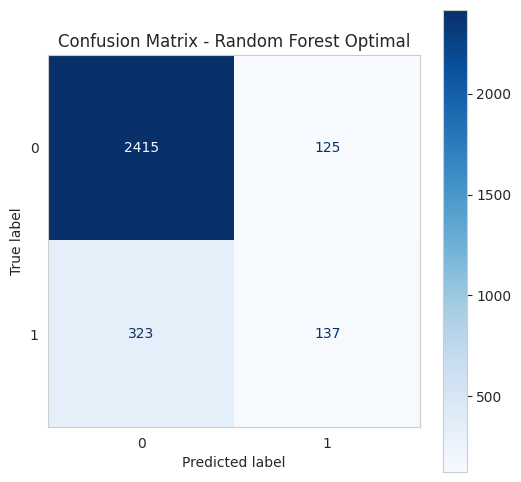

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Evaluasi Model Random Forest Terbaik
print("=== EVALUASI RANDOM FOREST (OPTIMAL) ===")
y_pred_rf = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# 2. Evaluasi Model Logistic Regression Terbaik
print("\n=== EVALUASI LOGISTIC REGRESSION (OPTIMAL) ===")
y_pred_lr = best_lr_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

# 3. Tampilkan Confusion Matrix untuk Model Terbaik (Misal: Random Forest)
cm = confusion_matrix(y_test, y_pred_rf, labels=best_rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_model.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Random Forest Optimal')
plt.grid(False) # Menghilangkan gridline agar visualisasi rapi
plt.show()